# TP1 - Procesamiento y Análisis de Imágenes

**Visión por Computadora I - FIUBA**

**Alumna:**  Sol Salazar

**Fecha:** 28/05/2026


## Parte 1: White patch

Algoritmo de corrección de iluminación/color

Idea:
- Asumir que el pixel más brillante debería ser blanco puro
- Escalar cada canal RGB para compensar la iluminación

Para cada canal se aplica:

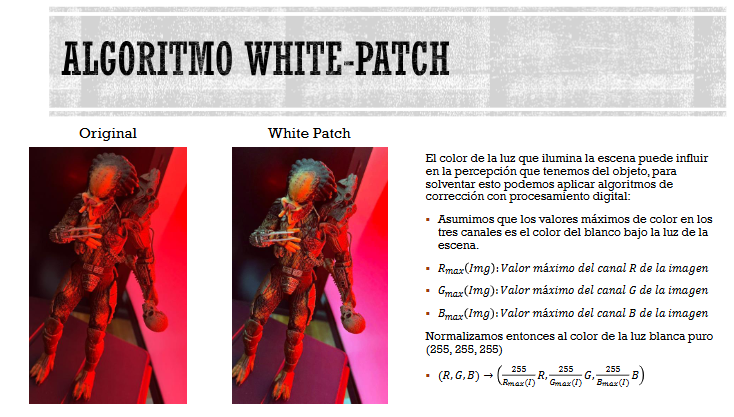

De esta manera, cada canal se normaliza independientemente, compensando posibles dominantes de color producidas por la iluminación.

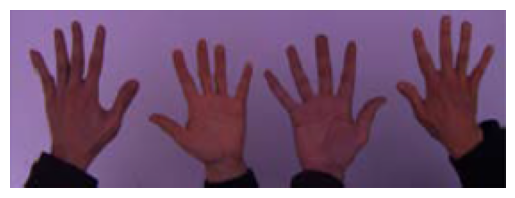

In [32]:
# Importar librerías necesarias
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread(r"C:\Users\pc\OneDrive\Escritorio\EIA\2do_Bimestre\VpC1\vision_computadora_I\Material_TPs\TP1\white_patch\test_blue.png")

# cv2.imshow('Original Image', img)   
# cv2.waitKey(0)
# cv2.destroyAllWindows()

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')
plt.show()

In [33]:
def white_patch(img):
    # Convertir a float para evitar problemas de saturación
    img_float = img.astype(np.float32)

    #separar canales RGB
    b, g, r = cv2.split(img_float)

    # máximos de cada canal
    max_b = np.max(b)
    max_g = np.max(g)
    max_r = np.max(r)

    # escalar cada canal por su máximo
    b = (b / max_b) * 255
    g = (g / max_g) * 255
    r = (r / max_r) * 255

    # merge de canales
    result = cv2.merge([b, g, r])

    # limitar valores a [0, 255] y convertir a uint8
    result = np.clip(result, 0, 255).astype(np.uint8)

    return result

Máximos RGB: [165. 138. 200.]
Factores de corrección: [1.5454545 1.8478261 1.275    ]
Diferencia media por canal RGB: [55.73345324 58.42723022 27.20705036]
Diferencia máxima por canal RGB: [ 90 117  55]
Máximos RGB: [210. 250. 171.]
Factores de corrección: [1.2142857 1.02      1.4912281]
Diferencia media por canal RGB: [27.2555036   2.11269784 40.55791367]
Diferencia máxima por canal RGB: [45  5 84]
Máximos RGB: [247. 157. 175.]
Factores de corrección: [1.0323887 1.6242038 1.4571428]
Diferencia media por canal RGB: [ 4.56177719 50.13197189 41.20165422]
Diferencia máxima por canal RGB: [ 8 98 80]
Máximos RGB: [255. 255. 255.]
Factores de corrección: [1. 1. 1.]
Diferencia media por canal RGB: [0. 0. 0.]
Diferencia máxima por canal RGB: [0 0 0]
Máximos RGB: [126. 252. 155.]
Factores de corrección: [2.0238094 1.0119047 1.6451613]
Diferencia media por canal RGB: [26.45582396  0.66342457 21.94196543]
Diferencia máxima por canal RGB: [129   3 100]
Máximos RGB: [170. 255. 172.]
Factores de cor

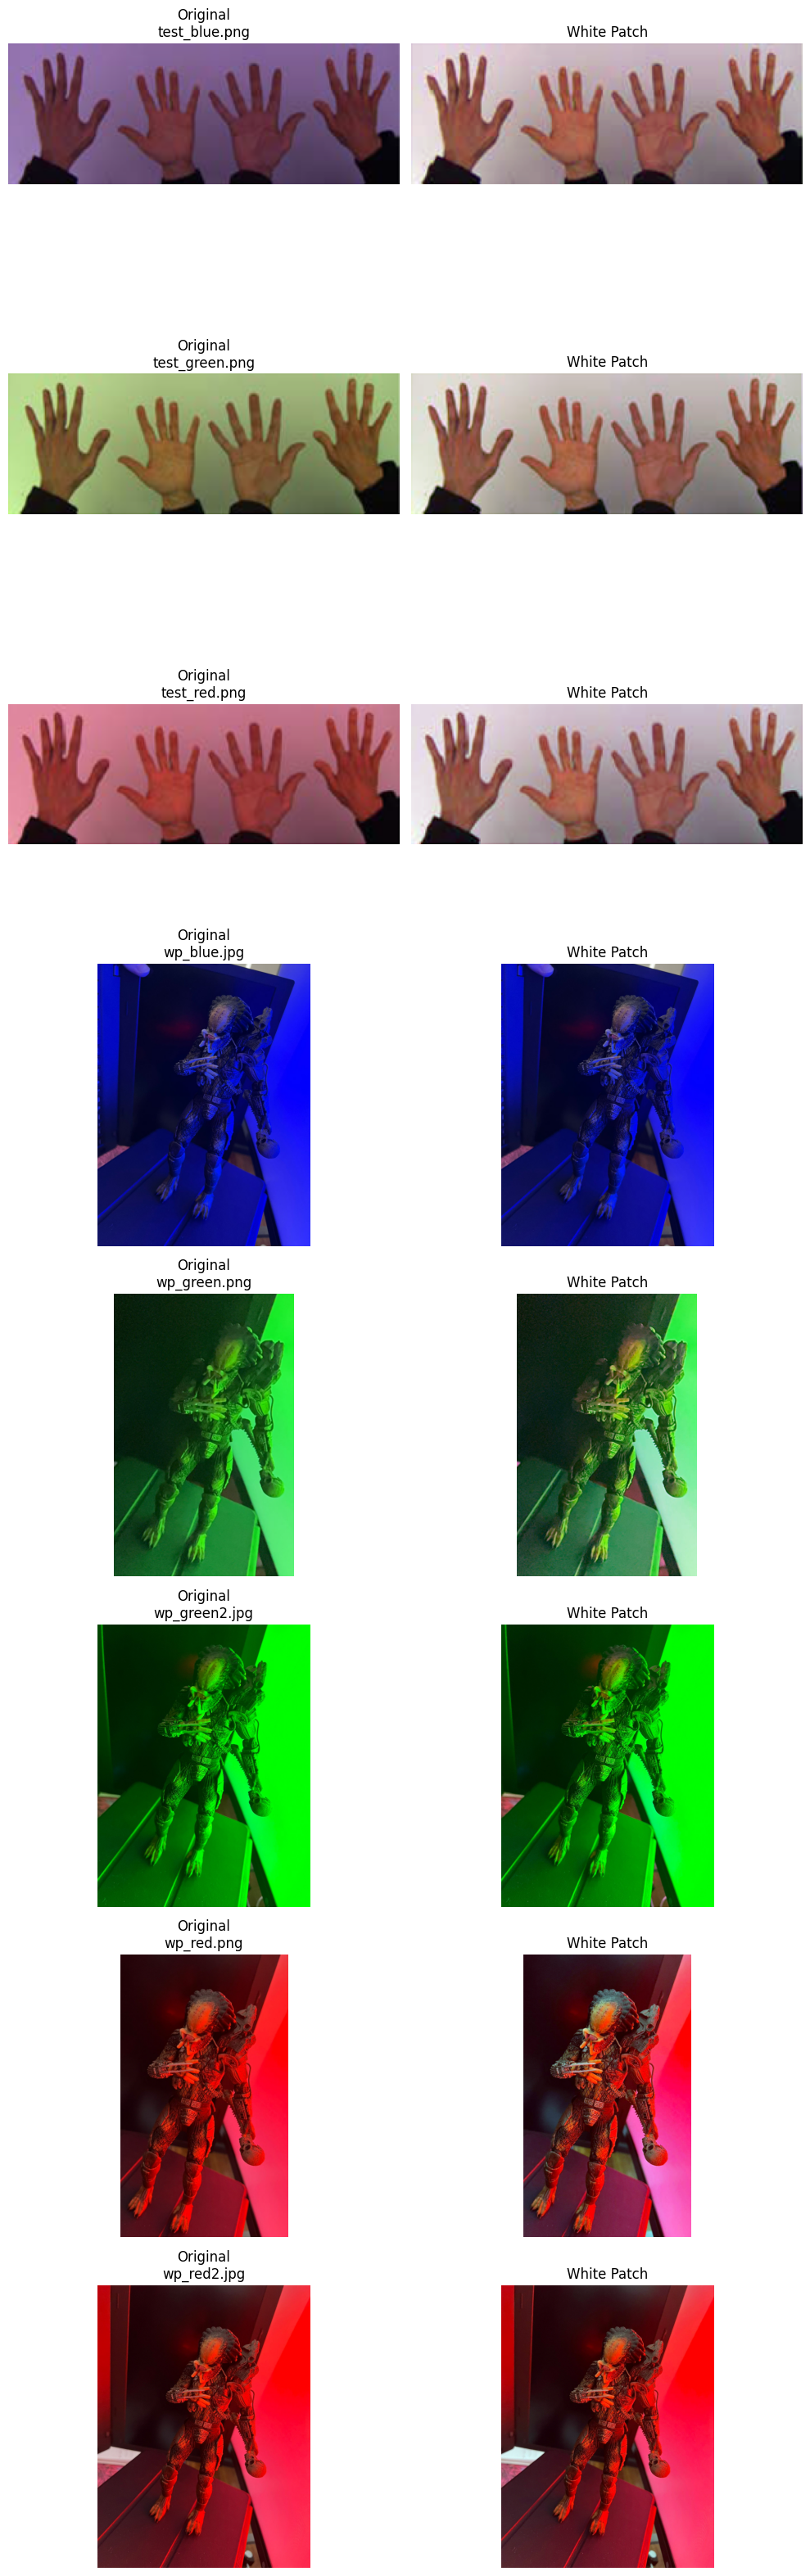

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

paths = [
    "./white_patch/test_blue.png",
    "./white_patch/test_green.png",
    "./white_patch/test_red.png",
    "./white_patch/wp_blue.jpg",
    "./white_patch/wp_green.png",
    "./white_patch/wp_green2.jpg",
    "./white_patch/wp_red.png",
    "./white_patch/wp_red2.jpg",
]

fig, axes = plt.subplots(len(paths), 2, figsize=(10, 4 * len(paths)))

for i, path in enumerate(paths):

    # leer imagen
    img = cv2.imread(path)

    # aplicar white patch
    corrected = white_patch(img)

    # convertir BGR -> RGB para matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    corrected_rgb = cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB)

    img_float = img_rgb.astype(np.float32)

    max_rgb = img_float.reshape(-1, 3).max(axis=0)
    factors = 255 / max_rgb

    print("Máximos RGB:", max_rgb)
    print("Factores de corrección:", factors)

    diff = np.abs(img_rgb.astype(np.int16) - corrected_rgb.astype(np.int16))

    print("Diferencia media por canal RGB:", diff.reshape(-1, 3).mean(axis=0))
    print("Diferencia máxima por canal RGB:", diff.reshape(-1, 3).max(axis=0))

    # mostrar original
    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f"Original\n{path.split('/')[-1]}")
    axes[i, 0].axis("off")

    # mostrar corregida
    axes[i, 1].imshow(corrected_rgb)
    axes[i, 1].set_title("White Patch")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

### Parte 1 — White Patch

El algoritmo White Patch es una técnica sencilla y computacionalmente barata para compensar dominantes de color debidas a la iluminación: escala cada canal RGB de modo que el píxel más brillante quede en 255, asumiendo que ese píxel debería ser blanco puro.

**Ventajas:** es efectivo cuando la escena contiene superficies realmente blancas o de alta reflectancia y la iluminación introduce un sesgo de color uniforme.

**Limitaciones observadas:** en algunas imágenes la corrección fue mínima o nula, como en wp_blue.jpg, donde los máximos de los tres canales ya eran [255, 255, 255], por lo que los factores de corrección fueron [1, 1, 1]. En estos casos, aunque la imagen tenga una dominante visible, White Patch no modifica la salida porque cada canal ya alcanza su valor máximo.

En las imágenes con iluminación roja o verde, el canal dominante ya se encontraba saturado o cercano al máximo, por lo que el algoritmo no lo reduce, sino que amplifica los otros canales. Esto puede mejorar parcialmente la imagen, pero no siempre elimina la dominante de forma natural, ya que la iluminación coloreada forma parte real de la escena.



---

## Parte 2: Análisis de histogramas en escala de grises

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread("./img1_tp.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("./img2_tp.png", cv2.IMREAD_GRAYSCALE)

print("Shape img1:", img1.shape)
print("Shape img2:", img2.shape)

Shape img1: (288, 287)
Shape img2: (288, 287)


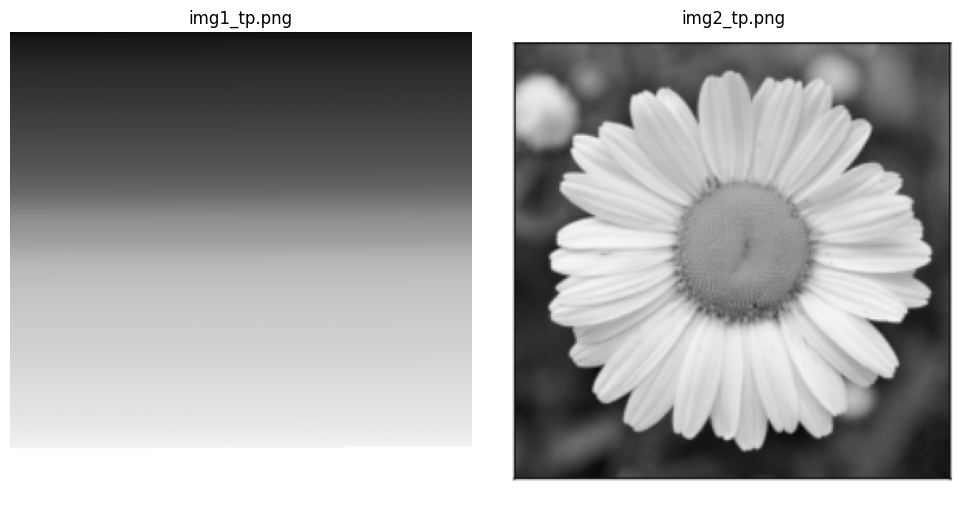

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img1, cmap="gray")
axes[0].set_title("img1_tp.png")
axes[0].axis("off")

axes[1].imshow(img2, cmap="gray")
axes[1].set_title("img2_tp.png")
axes[1].axis("off")

plt.tight_layout()
plt.show()

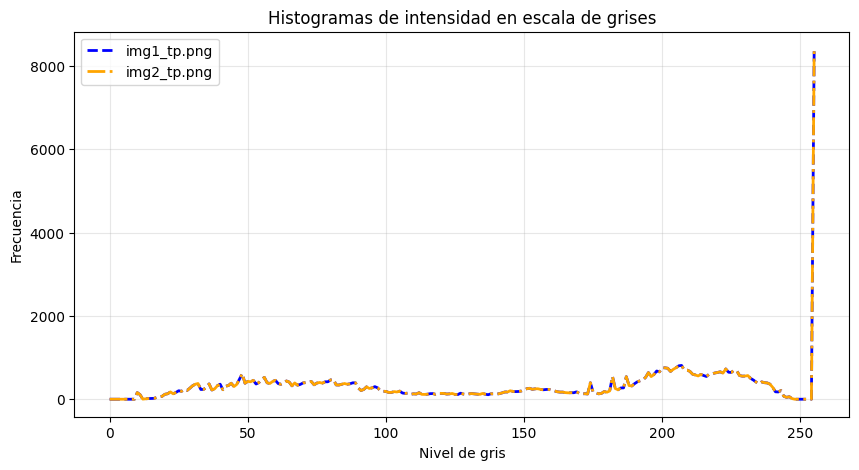

In [30]:
bins = 256

hist1 = cv2.calcHist([img1], [0], None, [bins], [0, 256])
hist2 = cv2.calcHist([img2], [0], None, [bins], [0, 256])

x = np.arange(256)

plt.figure(figsize=(10, 5))

plt.plot(x, hist1, color="blue", linestyle="--", linewidth=2, label="img1_tp.png")
plt.plot(x, hist2, color="orange", linestyle="-.", linewidth=2, label="img2_tp.png")

plt.title("Histogramas de intensidad en escala de grises")
plt.xlabel("Nivel de gris")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

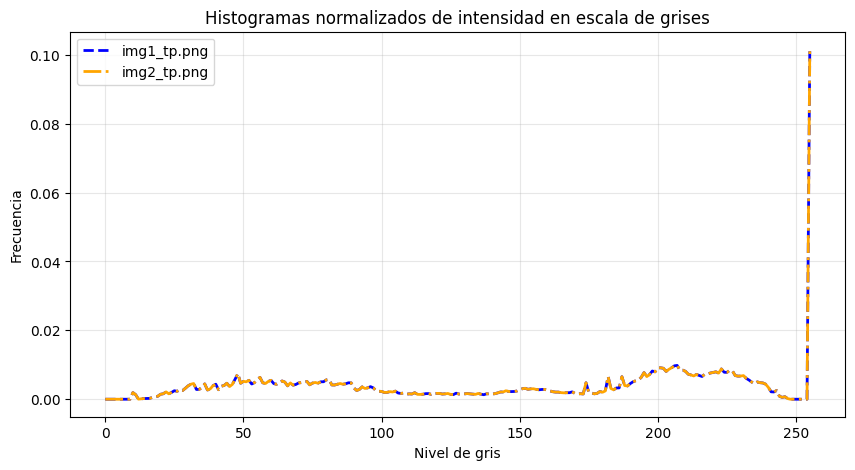

In [31]:
hist1_norm = hist1 / hist1.sum()
hist2_norm = hist2 / hist2.sum()


plt.figure(figsize=(10, 5))

plt.plot(x, hist1_norm, color="blue", linestyle="--", linewidth=2, label="img1_tp.png")
plt.plot(x, hist2_norm, color="orange", linestyle="-.", linewidth=2, label="img2_tp.png")

plt.title("Histogramas normalizados de intensidad en escala de grises")
plt.xlabel("Nivel de gris")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Elección de bins

Se eligieron **256 bins** porque las imágenes fueron leídas en escala de grises de 8 bits, donde cada píxel puede tomar valores enteros entre 0 y 255. Usar 256 bins garantiza que cada bin corresponde exactamente a un nivel de intensidad posible, sin pérdida de resolución tonal. Elegir menos bins (por ejemplo 64 o 128) implicaría agrupar varios niveles en un mismo bin, perdiendo detalle en la distribución; elegir más bins no tiene sentido porque no existen valores intermedios en imágenes de 8 bits.

---

### Comparación de histogramas

Al comparar las imágenes `img1_tp.png` e `img2_tp.png`, se observa que visualmente son muy diferentes: la primera corresponde a un gradiente, mientras que la segunda contiene una escena bordes marcados y textura.

Sin embargo, sus histogramas en escala de grises resultan prácticamente coincidentes. Esto ocurre porque el histograma representa únicamente la distribución global de intensidades, es decir, cuántos píxeles hay para cada nivel de gris, pero no conserva información sobre la ubicación espacial de esos píxeles.

Por lo tanto, dos imágenes con contenido visual completamente distinto pueden tener histogramas iguales o muy parecidos. Esto muestra una limitación importante de usar histogramas como features: pueden ser útiles para describir brillo, contraste o distribución de intensidades, pero no son suficientes para capturar forma, textura, bordes ni disposición espacial de los objetos.

Por lo tanto, los histogramas son útiles como features globales y complementarios, pero para tareas de clasificación o detección de imágenes es recomendable combinarlos con descriptores que capturen estructura espacial, como filtros de bordes (Sobel, Canny), por ejemplo.